In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [41]:
df = pd.read_csv("heart.csv")

print("First 5 rows:")
display(df.head())

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Dataset shape: (297, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

if 'condition' in df.columns:
    df = df.rename(columns={'condition': 'target'})

print("\nColumns now:", list(df.columns))
print("Target values:", sorted(df['target'].unique()))

Missing values per column:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Total missing values: 0

Columns now: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Target values: [np.int64(0), np.int64(1)]


In [4]:
print("Target variable values:")
print(df['target'].value_counts())

print(f"\nClass distribution:")
print(f"No heart disease (0): {(df['target'] == 0).sum()} patients ({(df['target'] == 0).mean()*100:.1f}%)")
print(f"Heart disease (1):    {(df['target'] == 1).sum()} patients ({(df['target'] == 1).mean()*100:.1f}%)")

Target variable values:
target
0    160
1    137
Name: count, dtype: int64

Class distribution:
No heart disease (0): 160 patients (53.9%)
Heart disease (1):    137 patients (46.1%)


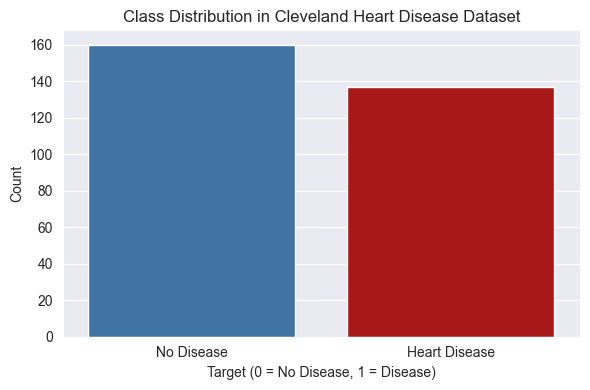

Chart saved.


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette=['#2E75B6', '#C00000'])
plt.title('Class Distribution in Cleveland Heart Disease Dataset')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print("Chart saved.")

In [6]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Target classes: {sorted(df['target'].unique())}")
print(f"No disease: {(df['target'] == 0).sum()}")
print(f"Heart disease: {(df['target'] == 1).sum()}")

print("\nDescriptive statistics:")
display(df.describe().T)

DATASET SUMMARY
Rows: 297
Columns: 14
Missing values: 0
Target classes: [np.int64(0), np.int64(1)]
No disease: 160
Heart disease: 137

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


In [7]:
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")

categorical_features = ['cp', 'restecg', 'slope', 'thal', 'ca']
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_features = ['sex', 'fbs', 'exang']

print("\nCategorical features:", categorical_features)
print("Continuous features: ", continuous_features)
print("Binary features:     ", binary_features)
print(f"\nTotal accounted for: {len(categorical_features) + len(continuous_features) + len(binary_features)} out of {X.shape[1]}")

Features shape: (297, 13)
Target shape:   (297,)

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Categorical features: ['cp', 'restecg', 'slope', 'thal', 'ca']
Continuous features:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary features:      ['sex', 'fbs', 'exang']

Total accounted for: 13 out of 13


In [8]:
print("=" * 50)
print("PREPROCESSING SUMMARY")
print("=" * 50)
print("1. Target column renamed to 'target'.")
print("2. Missing values checked.")
print("3. Input features separated from target.")
print("4. Continuous variables identified for scaling.")
print("5. Main evaluation will use stratified cross-validation.")
print("6. Scaling for Logistic Regression and SVM will happen INSIDE CV using pipelines.")

PREPROCESSING SUMMARY
1. Target column renamed to 'target'.
2. Missing values checked.
3. Input features separated from target.
4. Continuous variables identified for scaling.
5. Main evaluation will use stratified cross-validation.
6. Scaling for Logistic Regression and SVM will happen INSIDE CV using pipelines.


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_scaled_pipeline(estimator):
    return Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('scale', StandardScaler(), continuous_features)
            ],
            remainder='passthrough'
        )),
        ('model', estimator)
    ])

print("Cross-validation strategy defined.")
print("Type: Stratified 5-Fold")
print("Purpose: main model evaluation on the full dataset")

Cross-validation strategy defined.
Type: Stratified 5-Fold
Purpose: main model evaluation on the full dataset


In [10]:
models = {
    "Logistic Regression": make_scaled_pipeline(
        LogisticRegression(max_iter=1000, random_state=42)
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=1
    ),
    
    "SVM": make_scaled_pipeline(
        SVC(kernel='rbf', probability=True, random_state=42)
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42,
        n_jobs=1
    )
}

print("4 models defined successfully:")
for name in models.keys():
    print("-", name)

4 models defined successfully:
- Logistic Regression
- Random Forest
- SVM
- XGBoost


In [11]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'AUC-ROC': scores['test_roc_auc'].mean()
    })

print("Cross-validation complete.")


Cross-validation complete.


In [42]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='AUC-ROC', ascending=False).reset_index(drop=True)

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 60)
display(results_df.round(4))

MODEL PERFORMANCE COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.8354,0.8516,0.7889,0.8165,0.9100
1,Random Forest,0.8388,0.8616,0.7749,0.8131,0.9012
2,SVM,0.8389,0.8518,0.7966,0.8202,0.8981
3,XGBoost,0.8186,0.8272,0.7677,0.7943,0.8892


In [39]:
best_overall_model = results_df.iloc[0]['Model']
best_recall_model = results_df.sort_values(by='Recall', ascending=False).iloc[0]['Model']
top_2_models = results_df.head(2)['Model'].tolist()

print("=" * 60)
print("MODEL SELECTION SUMMARY")
print("=" * 60)
print(f"Best overall model (highest AUC-ROC): {best_overall_model}")
print(f"Best model for recall: {best_recall_model}")


MODEL SELECTION SUMMARY
Best overall model (highest AUC-ROC): Logistic Regression
Best model for recall: SVM


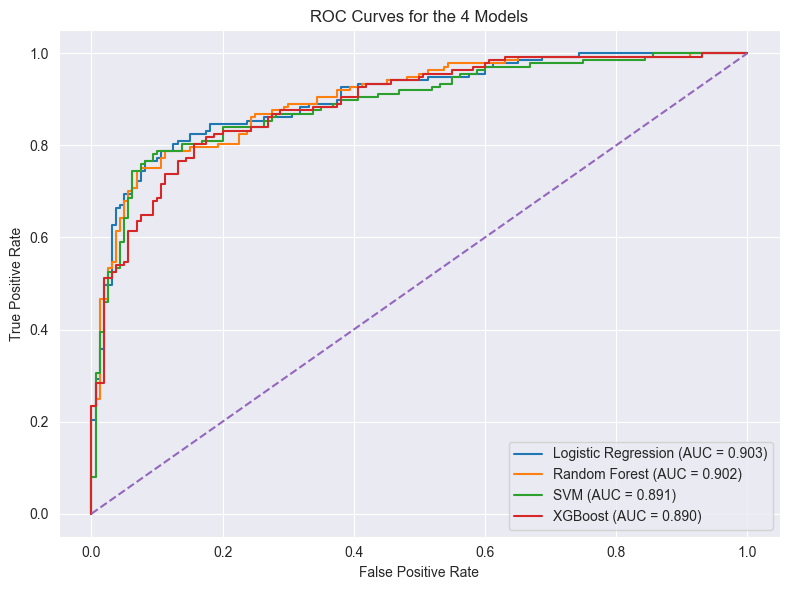

In [14]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]
    
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for the 4 Models")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Logistic Regression
X_lr = X.copy()
scaler_lr = StandardScaler()
X_lr[continuous_features] = scaler_lr.fit_transform(X_lr[continuous_features])

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_lr, y)

# Random Forest
X_rf = X.copy()
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    n_jobs=1
)
rf_model.fit(X_rf, y)

# XGBoost
X_xgb = X.copy()
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42,
    n_jobs=1
)
xgb_model.fit(X_xgb, y)

# SVM with scaled continuous features
X_svm = X.copy()
scaler_svm = StandardScaler()
X_svm[continuous_features] = scaler_svm.fit_transform(X_svm[continuous_features])

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
svm_model.fit(X_svm, y)

print("Final full-data models fitted successfully for SHAP.")

Final full-data models fitted successfully for SHAP.


In [43]:
import shap
shap.initjs()

def to_2d_shap_values(shap_output):

    if isinstance(shap_output, list):
        values = np.array(shap_output[1])   # class 1 for binary classification
    elif hasattr(shap_output, "values"):
        values = np.array(shap_output.values)
    else:
        values = np.array(shap_output)
    
    if values.ndim == 3:
        values = values[:, :, 1]  # class 1
    return values

def make_shap_table(shap_values, feature_names):
    importance = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    shap_df['Rank'] = np.arange(1, len(shap_df) + 1)
    return shap_df

print("SHAP ready.")

SHAP ready.


Random Forest SHAP shape: (297, 13)


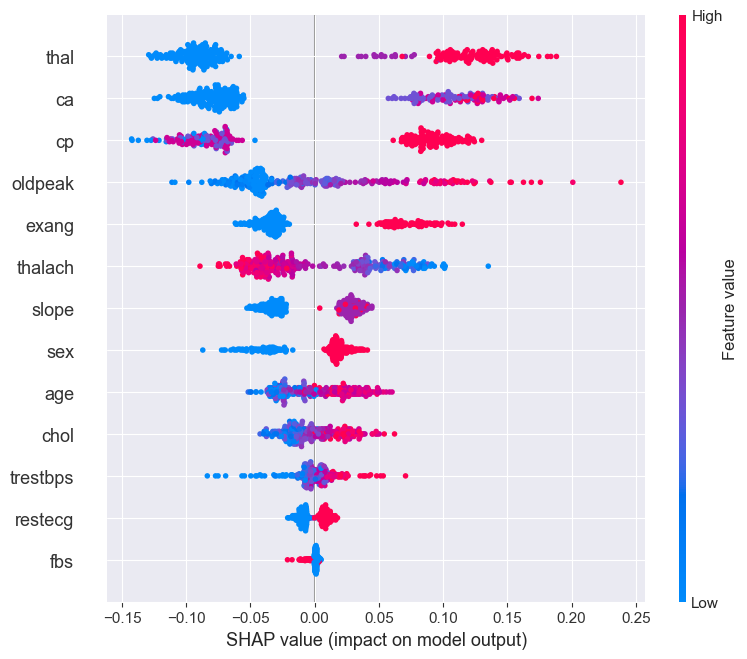

Random Forest SHAP ranking table:


,Feature,Importance,Rank
0,thal,0.103378,1
1,ca,0.092751,2
2,cp,0.089025,3
3,oldpeak,0.050662,4
4,exang,0.047214,5
5,thalach,0.044113,6
6,slope,0.030785,7
7,sex,0.026141,8
8,age,0.023047,9
9,chol,0.017575,10


In [44]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_output_rf = explainer_rf(X_rf)
shap_values_rf = to_2d_shap_values(shap_output_rf)

print("Random Forest SHAP shape:", shap_values_rf.shape)

shap.summary_plot(shap_values_rf, X_rf, feature_names=X.columns)

shap_df_rf = make_shap_table(shap_values_rf, X.columns)
print("Random Forest SHAP ranking table:")
display(shap_df_rf)

Logistic Regression SHAP shape: (297, 13)


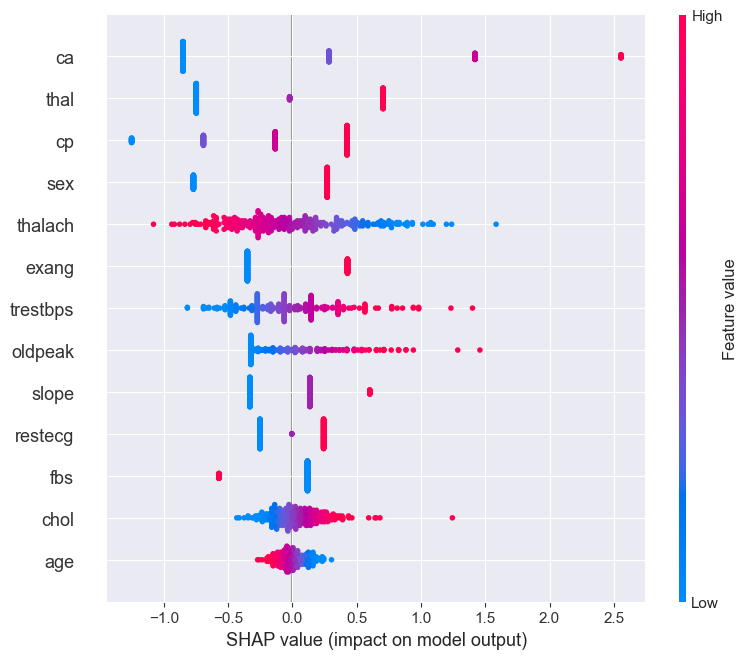

Logistic Regression SHAP ranking table:


,Feature,Importance,Rank
0,ca,0.914955,1
1,thal,0.687401,2
2,cp,0.451616,3
3,sex,0.432240,4
4,thalach,0.378393,5
5,exang,0.375737,6
6,trestbps,0.293185,7
7,oldpeak,0.272557,8
8,slope,0.259981,9
9,restecg,0.244149,10


In [45]:
explainer_lr = shap.LinearExplainer(lr_model, X_lr)
shap_output_lr = explainer_lr(X_lr)
shap_values_lr = to_2d_shap_values(shap_output_lr)

print("Logistic Regression SHAP shape:", shap_values_lr.shape)

shap.summary_plot(shap_values_lr, X_lr, feature_names=X.columns)

shap_df_lr = make_shap_table(shap_values_lr, X.columns)
print("Logistic Regression SHAP ranking table:")
display(shap_df_lr)

XGBoost SHAP shape: (297, 13)


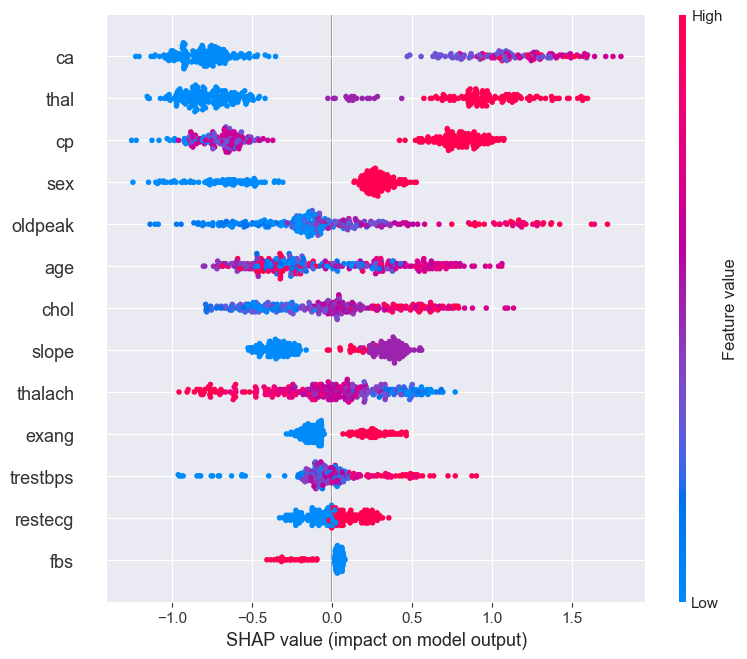

XGBoost SHAP ranking table:


,Feature,Importance,Rank
0,ca,0.935211,1
1,thal,0.826462,2
2,cp,0.753868,3
3,sex,0.417463,4
4,oldpeak,0.399700,5
5,age,0.393479,6
6,chol,0.347015,7
7,slope,0.344402,8
8,thalach,0.311481,9
9,exang,0.171522,10


In [46]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_output_xgb = explainer_xgb(X_xgb)
shap_values_xgb = to_2d_shap_values(shap_output_xgb)

print("XGBoost SHAP shape:", shap_values_xgb.shape)

shap.summary_plot(shap_values_xgb, X_xgb, feature_names=X.columns)

shap_df_xgb = make_shap_table(shap_values_xgb, X.columns)
print("XGBoost SHAP ranking table:")
display(shap_df_xgb)

100%|██████████| 297/297 [39:56<00:00,  8.07s/it] 


SVM SHAP shape: (297, 13)


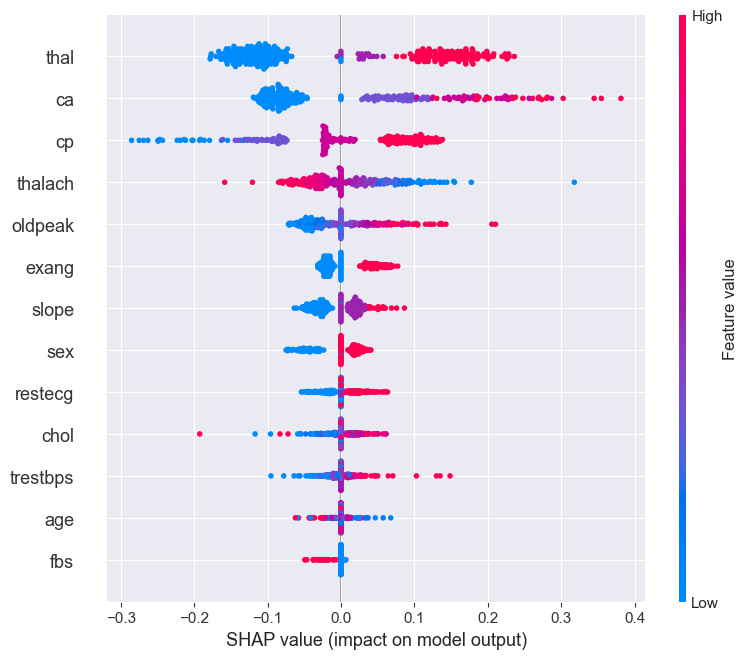

SVM SHAP ranking table:


,Feature,Importance,Rank
0,thal,0.124582,1
1,ca,0.105272,2
2,cp,0.082171,3
3,thalach,0.044739,4
4,oldpeak,0.040540,5
5,exang,0.027065,6
6,slope,0.026321,7
7,sex,0.025904,8
8,restecg,0.017069,9
9,chol,0.013656,10


In [20]:
background_svm = shap.sample(X_svm, 100, random_state=42)

explainer_svm = shap.KernelExplainer(
    svm_model.predict_proba,
    background_svm
)

shap_output_svm = explainer_svm(X_svm)
shap_values_svm = to_2d_shap_values(shap_output_svm)

print("SVM SHAP shape:", shap_values_svm.shape)

shap.summary_plot(shap_values_svm, X_svm, feature_names=X.columns)

shap_df_svm = make_shap_table(shap_values_svm, X.columns)
print("SVM SHAP ranking table:")
display(shap_df_svm)

In [21]:
all_shap_tables = {
    "Random Forest": shap_df_rf.copy(),
    "Logistic Regression": shap_df_lr.copy(),
    "XGBoost": shap_df_xgb.copy(),
    "SVM": shap_df_svm.copy()
}

combined_shap_ranks = pd.DataFrame({'Feature': X.columns})

for model_name, shap_df in all_shap_tables.items():
    rank_col = model_name.replace(" ", "_") + "_Rank"
    temp = shap_df[['Feature', 'Rank']].rename(columns={'Rank': rank_col})
    combined_shap_ranks = combined_shap_ranks.merge(temp, on='Feature')

print("=" * 80)
print("COMBINED SHAP RANK COMPARISON ACROSS ALL 4 MODELS")
print("=" * 80)
display(combined_shap_ranks)

COMBINED SHAP RANK COMPARISON ACROSS ALL 4 MODELS


,Feature,Random_Forest_Rank,Logistic_Regression_Rank,XGBoost_Rank,SVM_Rank
0,age,9,13,6,12
1,sex,8,4,4,8
2,cp,3,3,3,3
3,trestbps,11,7,11,11
4,chol,10,12,7,10
5,fbs,13,11,13,13
6,restecg,12,10,12,9
7,thalach,6,5,9,4
8,exang,5,6,10,6
9,oldpeak,4,8,5,5


In [22]:
all_shap_tables = {
    "Random Forest": shap_df_rf.copy(),
    "Logistic Regression": shap_df_lr.copy(),
    "XGBoost": shap_df_xgb.copy(),
    "SVM": shap_df_svm.copy()
}

combined_shap_ranks = pd.DataFrame({'Feature': X.columns})

for model_name, shap_df in all_shap_tables.items():
    rank_col = model_name.replace(" ", "_") + "_Rank"
    temp = shap_df[['Feature', 'Rank']].rename(columns={'Rank': rank_col})
    combined_shap_ranks = combined_shap_ranks.merge(temp, on='Feature')

print("=" * 80)
print("COMBINED SHAP RANK COMPARISON ACROSS ALL 4 MODELS")
print("=" * 80)
display(combined_shap_ranks)

COMBINED SHAP RANK COMPARISON ACROSS ALL 4 MODELS


,Feature,Random_Forest_Rank,Logistic_Regression_Rank,XGBoost_Rank,SVM_Rank
0,age,9,13,6,12
1,sex,8,4,4,8
2,cp,3,3,3,3
3,trestbps,11,7,11,11
4,chol,10,12,7,10
5,fbs,13,11,13,13
6,restecg,12,10,12,9
7,thalach,6,5,9,4
8,exang,5,6,10,6
9,oldpeak,4,8,5,5


In [23]:
top5_all = (
    shap_df_rf['Feature'].head(5).tolist() +
    shap_df_lr['Feature'].head(5).tolist() +
    shap_df_xgb['Feature'].head(5).tolist() +
    shap_df_svm['Feature'].head(5).tolist()
)

top5_counts = pd.Series(top5_all).value_counts().reset_index()
top5_counts.columns = ['Feature', 'Top5_Appearances']

print("=" * 70)
print("TOP 5 FEATURE STABILITY ACROSS MODELS")
print("=" * 70)
display(top5_counts)

TOP 5 FEATURE STABILITY ACROSS MODELS


,Feature,Top5_Appearances
0,thal,4
1,ca,4
2,cp,4
3,oldpeak,3
4,sex,2
5,thalach,2
6,exang,1


In [24]:
top10_all = (
    shap_df_rf['Feature'].head(10).tolist() +
    shap_df_lr['Feature'].head(10).tolist() +
    shap_df_xgb['Feature'].head(10).tolist() +
    shap_df_svm['Feature'].head(10).tolist()
)

top10_counts = pd.Series(top10_all).value_counts().reset_index()
top10_counts.columns = ['Feature', 'Top10_Appearances']

print("=" * 70)
print("TOP 10 FEATURE STABILITY ACROSS MODELS")
print("=" * 70)
display(top10_counts)

TOP 10 FEATURE STABILITY ACROSS MODELS


,Feature,Top10_Appearances
0,thal,4
1,ca,4
2,cp,4
3,oldpeak,4
4,exang,4
5,thalach,4
6,slope,4
7,sex,4
8,chol,3
9,age,2


In [25]:
rank_summary = combined_shap_ranks.copy()

rank_summary['Mean_Rank'] = rank_summary[
    ['Random_Forest_Rank', 'Logistic_Regression_Rank', 'XGBoost_Rank', 'SVM_Rank']
].mean(axis=1)

rank_summary = rank_summary.sort_values(by='Mean_Rank').reset_index(drop=True)

print("=" * 80)
print("AVERAGE SHAP RANK ACROSS ALL 4 MODELS")
print("=" * 80)
display(rank_summary)

AVERAGE SHAP RANK ACROSS ALL 4 MODELS


,Feature,Random_Forest_Rank,Logistic_Regression_Rank,XGBoost_Rank,SVM_Rank,Mean_Rank
0,thal,1,2,2,1,1.50
1,ca,2,1,1,2,1.50
2,cp,3,3,3,3,3.00
3,oldpeak,4,8,5,5,5.50
4,thalach,6,5,9,4,6.00
5,sex,8,4,4,8,6.00
6,exang,5,6,10,6,6.75
7,slope,7,9,8,7,7.75
8,chol,10,12,7,10,9.75
9,trestbps,11,7,11,11,10.00


In [33]:
clinical_reference = pd.DataFrame({
    'Feature': [
        'ca',
        'thal',
        'oldpeak',
        'cp',
        'exang',
        'slope',
        'restecg',
        'thalach',
        'age',
        'sex',
        'trestbps',
        'chol',
        'fbs',
    ],
    'Clinical_Rank': list(range(1, 14))
})

print("Clinically Plausible benchmark:")
print("=" * 60)
print(clinical_reference.to_string(index=False))

Clinical benchmark:
 Feature  Clinical_Rank
      ca              1
    thal              2
 oldpeak              3
      cp              4
   exang              5
   slope              6
 restecg              7
 thalach              8
     age              9
     sex             10
trestbps             11
    chol             12
     fbs             13


In [47]:
print("CLINICAL ALIGNMENT AUDIT — SPEARMAN RANK CORRELATION")
print("=" * 60)
print("Comparing each model's SHAP feature rankings against")
print("a source-anchored clinically informed benchmark")
print("=" * 60)

shap_tables = {
    'Random Forest': shap_df_rf,
    'Logistic Regression': shap_df_lr,
    'XGBoost': shap_df_xgb,
    'SVM': shap_df_svm
}

spearman_results = []

for model_name, shap_df in shap_tables.items():
    merged = clinical_reference.merge(
        shap_df[['Feature', 'Rank']].rename(columns={'Rank': 'SHAP_Rank'}),
        on='Feature'
    )
    
    rho, p_value = spearmanr(merged['Clinical_Rank'], merged['SHAP_Rank'])
    
    if rho >= 0.6:
        interpretation = "Strong alignment"
    elif rho >= 0.3:
        interpretation = "Moderate alignment"
    elif rho >= 0.0:
        interpretation = "Weak alignment"
    else:
        interpretation = "Inverse / no alignment"
    
    sig = "significant" if p_value < 0.05 else "not significant"
    
    print(f"\n{model_name}")
    print(f"  Spearman rho: {rho:.4f}")
    print(f"  p-value:      {p_value:.4f} ({sig})")
    print(f"  Interpretation: {interpretation}")
    
    spearman_results.append({
        'Model': model_name,
        'Spearman_rho': round(rho, 4),
        'p_value': round(p_value, 4),
        'Significant': p_value < 0.05,
        'Interpretation': interpretation
    })

spearman_df = pd.DataFrame(spearman_results)
spearman_df = spearman_df.sort_values(by='Spearman_rho', ascending=False).reset_index(drop=True)

print("\nSUMMARY TABLE")
print("=" * 60)
display(spearman_df)

CLINICAL ALIGNMENT AUDIT — SPEARMAN RANK CORRELATION
Comparing each model's SHAP feature rankings against
a source-anchored clinically informed benchmark

Random Forest
  Spearman rho: 0.8846
  p-value:      0.0001 (significant)
  Interpretation: Strong alignment

Logistic Regression
  Spearman rho: 0.6538
  p-value:      0.0153 (significant)
  Interpretation: Strong alignment

XGBoost
  Spearman rho: 0.6429
  p-value:      0.0178 (significant)
  Interpretation: Strong alignment

SVM
  Spearman rho: 0.8736
  p-value:      0.0001 (significant)
  Interpretation: Strong alignment

SUMMARY TABLE


,Model,Spearman_rho,p_value,Significant,Interpretation
0,Random Forest,0.8846,0.0001,True,Strong alignment
1,SVM,0.8736,0.0001,True,Strong alignment
2,Logistic Regression,0.6538,0.0153,True,Strong alignment
3,XGBoost,0.6429,0.0178,True,Strong alignment


In [28]:
print("FULL CLINICAL ALIGNMENT AUDIT TABLES")
print("=" * 70)

for model_name, shap_df in shap_tables.items():
    merged = clinical_reference.merge(
        shap_df[['Feature', 'Rank']].rename(columns={'Rank': 'SHAP_Rank'}),
        on='Feature'
    )
    
    merged['Rank_Difference'] = merged['SHAP_Rank'] - merged['Clinical_Rank']
    merged['Abs_Difference'] = merged['Rank_Difference'].abs()
    merged = merged.sort_values('Clinical_Rank').reset_index(drop=True)
    
    print(f"\n{model_name}")
    print("-" * 70)
    print(merged[['Feature', 'Clinical_Rank', 'SHAP_Rank',
                  'Rank_Difference', 'Abs_Difference']].to_string(index=False))
    print(f"Mean absolute rank difference: {merged['Abs_Difference'].mean():.2f}")

FULL CLINICAL ALIGNMENT AUDIT TABLES

Random Forest
----------------------------------------------------------------------
 Feature  Clinical_Rank  SHAP_Rank  Rank_Difference  Abs_Difference
      ca              1          2                1               1
    thal              2          1               -1               1
      cp              3          3                0               0
 oldpeak              4          4                0               0
   exang              5          5                0               0
   slope              6          7                1               1
 thalach              7          6               -1               1
 restecg              8         12                4               4
     age              9          9                0               0
trestbps             10         11                1               1
    chol             11         10               -1               1
     fbs             12         13                1          

In [29]:
mean_abs_diff_results = []

for model_name, shap_df in shap_tables.items():
    merged = clinical_reference.merge(
        shap_df[['Feature', 'Rank']].rename(columns={'Rank': 'SHAP_Rank'}),
        on='Feature'
    )
    merged['Abs_Difference'] = (merged['SHAP_Rank'] - merged['Clinical_Rank']).abs()
    
    mean_abs_diff_results.append({
        'Model': model_name,
        'Mean_Absolute_Rank_Difference': merged['Abs_Difference'].mean()
    })

mean_abs_diff_df = pd.DataFrame(mean_abs_diff_results)
mean_abs_diff_df = mean_abs_diff_df.sort_values(by='Mean_Absolute_Rank_Difference').reset_index(drop=True)

print("=" * 70)
print("MEAN ABSOLUTE RANK DIFFERENCE BY MODEL")
print("=" * 70)
display(mean_abs_diff_df.round(4))

MEAN ABSOLUTE RANK DIFFERENCE BY MODEL


,Model,Mean_Absolute_Rank_Difference
0,Random Forest,1.2308
1,SVM,1.5385
2,Logistic Regression,2.3077
3,XGBoost,2.4615


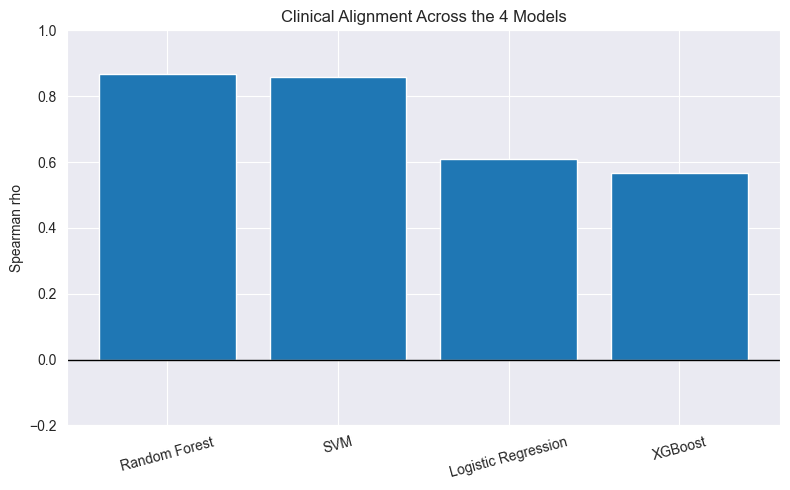

In [30]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    spearman_df['Model'],
    spearman_df['Spearman_rho']
)

plt.axhline(0, color='black', linewidth=1)
plt.ylim(-0.2, 1.0)
plt.ylabel("Spearman rho")
plt.title("Clinical Alignment Across the 4 Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [31]:
print("=" * 70)
print("INTERPRETATION NOTES")
print("=" * 70)
print("1. The 4 classical ML models were first compared using stratified 5-fold cross-validation.")
print("2. SHAP was then applied to all 4 models to obtain feature-importance rankings.")
print("3. Cross-model stability analysis identified a stable core of influential features.")
print("4. A source-anchored clinically informed benchmark was constructed for alignment auditing.")
print("5. Spearman's rank correlation was used to quantify agreement between SHAP rankings and the benchmark.")
print("6. This audit should be interpreted as a plausibility check, not proof of clinical validity.")

INTERPRETATION NOTES
1. The 4 classical ML models were first compared using stratified 5-fold cross-validation.
2. SHAP was then applied to all 4 models to obtain feature-importance rankings.
3. Cross-model stability analysis identified a stable core of influential features.
4. A source-anchored clinically informed benchmark was constructed for alignment auditing.
5. Spearman's rank correlation was used to quantify agreement between SHAP rankings and the benchmark.
6. This audit should be interpreted as a plausibility check, not proof of clinical validity.
